# Lecture 12 — Molecular Equilibrium & Molecular Bands

*Stellar Spectroscopy from Scratch — rebuilding the physics of ATLAS and SYNTHE from first principles*

*Yuan-Sen Ting*

*Written in collaboration with **Claude Opus 4.8**, under the author's supervision. Schematics generated with **Gemini 3 Pro** (Nano Banana).*

*Every result in this book is checked against reference values computed with [**pykurucz**](https://arxiv.org/abs/2603.11693) — a pure-Python implementation of Kurucz's ATLAS12 and SYNTHE — shipped beside the lectures as small data files, so the notebooks need only NumPy to run.*

---

**Learning objectives.** By the end of this lecture you will be able to:

- Say **why cool stars form molecules** and warm ones do not, and write the chemical equilibrium of a diatomic molecule as a **Saha-like law** — the dissociation energy $D_0$ plus a temperature polynomial for the equilibrium constant $\log K(T)$.
- Read the production code's molecular data file `molecules.dat`, decode a molecule's element code, and evaluate the formation constant $\log K_f(T)$ for **TiO** from its tabulated coefficients.
- Turn a molecular number density into the line-opacity driver **XNFDOP** $= n_{\rm mol}/(\rho\,\Delta\lambda_D/\lambda)$, recomputing the molecular Doppler width from the species mass exactly as the synthesis does.
- Feed those populations into the **same Voigt line-accumulation engine** as the atomic lines (Lectures 4–6) and reproduce the production TiO **band opacity** over 1.17 million molecular lines to machine precision.
- Run the cool M-dwarf TiO **bandhead spectrum** through the JOSH solver (Lecture 8) and match the reference to machine precision — then read off **why an M dwarf's spectrum looks nothing like the Sun's**.

## Introduction

Everything so far has been built for a warm star. The Sun's photosphere sits near 5800 K, hot enough that the gas is atomic: hydrogen is neutral but the metals are partly ionised, and the spectrum (Lectures 4–6) is a forest of **atomic** lines on an H$^-$ continuum. Drop the temperature to 3500 K — a mid M dwarf, the most common kind of star in the Galaxy — and the chemistry changes. Atoms begin to **stick together** into molecules, and because a molecule has thousands of closely spaced rovibrational transitions, those transitions merge into broad **bands** that dominate the optical and near-infrared spectrum. The strongest in the red is **titanium oxide**, TiO, whose band heads carve deep steps into the continuum and are the defining signature of the M spectral class.

To synthesise such a spectrum we need two new pieces, and we already own the rest. The first is the **molecular abundance**: how much TiO is there at each depth? That is a chemical-equilibrium problem — the balance Ti + O $\rightleftharpoons$ TiO — and we will see it is governed by a law with exactly the structure of the **Saha equation** of Lecture 2, with the ionisation energy replaced by the molecule's **dissociation energy** $D_0$. The second is the **band opacity**: once we know the population, each molecular line is broadened and accumulated onto the wavelength grid by the very **same Voigt engine** we built for atomic lines in Lectures 4–6. Nothing about the line physics changes; only the source of the populations does.

This lecture assembles those two pieces for a cool M dwarf (Teff = 3500 K, $\log g$ = 5.0, solar metallicity) over 705–718 nm, where a TiO band head falls. The molecular catalogue here is large — 1.17 million lines in that 13 nm window — and we reproduce the production band opacity and the emergent spectrum to machine precision against the reference.

## Why cool stars form molecules: Saha for molecules

A diatomic molecule AB is held together by a **dissociation energy** $D_0$: that much energy must be supplied to break it into free atoms A and B. The reaction A + B $\rightleftharpoons$ AB is in chemical equilibrium, and the law of mass action — the same statistical-mechanics argument that gave us the Saha equation in Lecture 2, only now for a bound *molecular* state instead of a bound *electronic* state — fixes the ratio of number densities:

$$
\frac{n_A\,n_B}{n_{AB}} = K_d(T) .
$$

$K_d(T)$ is the **dissociation equilibrium constant**, and it has the familiar Saha shape: a partition-function ratio times a Boltzmann factor in the binding energy,

$$
K_d(T) = \frac{Z_A\,Z_B}{Z_{AB}}\left(\frac{2\pi m_{AB}^* kT}{h^2}\right)^{3/2} e^{-D_0/kT} ,
$$

where the $Z$ are partition functions and $m_{AB}^*$ is the reduced mass. The single fact that drives the chemistry is the **Boltzmann factor** $e^{-D_0/kT}$. At the Sun's 5800 K the thermal energy $kT \approx 0.5$ eV is comparable to a typical $D_0$ of a few eV, so $e^{-D_0/kT}$ is not tiny and dissociation wins — molecules are scarce. At an M dwarf's 3500 K, $kT \approx 0.3$ eV, the exponent is several times larger, and the balance tips hard toward the **bound** molecule. This is the whole story of why cool stars are molecular and hot stars are atomic, and it is the same exponential temperature sensitivity that makes the Saha ionisation balance so steep.

It is often more convenient to track the inverse — the **formation** constant $K_f(T) \equiv n_{AB}/(n_A n_B) = 1/K_d(T)$, which carries the binding factor as $e^{+D_0/kT}$, so it is **large in cool gas** (much molecule formed) and small in hot gas. The production code tabulates this formation form, and that is the quantity we evaluate below.

![In hot gas the atoms (Ti, O) stay free; as the gas cools the formation balance Ti + O ⇌ TiO tips toward the bound molecule, governed by a Saha-like equilibrium set by temperature and the dissociation energy D0. The spectral consequence is on the right: a few isolated atomic lines, versus the millions of molecular rovibrational lines that blend into a band with a sharp bandhead.](resources/figures/s11_molecules.png)

The production code does not store $K_f(T)$ as a closed form. Instead `molecules.dat` gives, for each molecule, the dissociation energy $D_0$ and a short **temperature polynomial** that packages the partition-function ratio and the $(kT)^{3/2}$ phase-space factor into one fit. The Fortran NMOLEC routine evaluates, for a molecule built from $n_{\rm comp}$ atoms with net charge `ion`,

$$
\log K_f(T) = \frac{D_0}{kT} - E_1 + E_2 T - E_3 T^2 + E_4 T^3 - E_5 T^4 + E_6 T^5 \;-\; \tfrac32\,(n_{\rm comp} - 2\,{\rm ion} - 1)\,\log T ,
$$

with $kT$ in electron-volts (the Fortran constant $kT = 8.6171\times10^{-5}\,T$, *not* the CODATA value — we keep the code's constant so the numbers match). The first term is the binding Boltzmann factor $D_0/kT$ (positive, so $K_f$ grows as the gas cools); the polynomial $E_1..E_6$ is the partition-function fit; the last term is the $(kT)^{3/2}$ phase-space scaling per atom removed. We will evaluate this for TiO in a moment. The coupled set of these balances over all molecules and all elements — conserving each element's total nuclei and the charge — is solved by a Newton iteration (the routine NMOLEC) at the moment the atmosphere is converted; we take its result for the populations and focus this lecture on what those populations *do* to the spectrum.

## Setting up: the cool M-dwarf model and the molecular data

We load the reference cool M-dwarf model atmosphere and the molecular line list. The model `m3500g50.npz` is the analogue of the solar atmosphere used in Lectures 1–11 — taken as given here, exactly as we took the Sun as given — but computed for Teff = 3500 K, $\log g$ = 5.0. Crucially its conversion ran the full molecular-equilibrium solver, so it already carries the molecular number densities we need: they live in `population_per_ion` at the molecular slot (index 5), indexed by element. We also pull the per-depth temperature, density, electron density, the Boltzmann factor `hckt`, and the microturbulence.

In [1]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt

# shared plot styling for the whole notebook
plt.rcParams.update({"figure.figsize": (7.2, 4.3), "figure.dpi": 120, "savefig.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "font.size": 11, "axes.titlesize": 12.5, "axes.labelsize": 11.5})

# load the cool M-dwarf model atmosphere (taken as GIVEN, exactly as we took the Sun)
REF = pathlib.Path("..") / "reference"
atm = np.load(REF / "m3500g50.npz")
T   = atm["temperature"].astype(float)              # K, per depth (80 layers)
rho = atm["mass_density"].astype(float)             # g/cm^3
xne = atm["electron_density"].astype(float)         # cm^-3

# hckt = hc/kT in 1/cm, the Boltzmann exponent factor; vturb = microturbulence per depth
hckt = atm["hckt"].astype(float)
vturb = atm["turbulent_velocity"].astype(float)     # cm/s

print(f"M dwarf: Teff={float(atm['teff']):.0f} K, logg={float(atm['glog']):.1f}, "
      f"{T.size} depths, T = {T.min():.0f}..{T.max():.0f} K")

M dwarf: Teff=3500 K, logg=5.0, 80 depths, T = 2464..5250 K


## Reading `molecules.dat`: TiO's dissociation data

The dissociation table `molecules.dat` is a flat text file: each molecule is a line whose first field is a **code** that encodes the constituent atoms, followed by the dissociation energy and the equilibrium-constant polynomial. The code packs each element's atomic number into a base-100 digit pair — TiO is titanium ($Z=22$) plus oxygen ($Z=8$), so its code is $22\times100 + 8 = 2208$, written as `822.00` in the file's two-decimal convention (the file lists the lighter element in the high digits; here oxygen 08 then titanium 22 reads as `0822`). We parse the file just far enough to find TiO and read its seven coefficients.

In [2]:
def read_molecules_dat(path):
    """Parse molecules.dat into {code: (D0, [E1..E6])}: the dissociation table.

    Each entry is code, D0, then up to six polynomial coefficients E1..E6; trailing
    blank fields (here E6 for TiO) default to zero, so we pad the list to length six.
    """
    table = {}
    for line in path.read_text().splitlines():
        parts = line.split()
        # skip headers / blank lines
        if len(parts) < 2:
            continue
        try:
            code = float(parts[0])                  # element code, e.g. 822.0 for TiO
            # D0 then the (up to 6) polynomial terms
            vals = [float(p) for p in parts[1:8]]
        except ValueError:
            # non-numeric line -> not a molecule entry
            continue
        if len(vals) >= 1:
            # pad missing coefficients with 0
            E = (vals[1:] + [0.0, 0.0, 0.0, 0.0, 0.0, 0.0])[:6]
            # store D0 (eV) and the six-term E1..E6 fit, keyed by the rounded element code
            table[round(code)] = (vals[0], E)
    return table

mol_table = read_molecules_dat(REF / "molecules.dat")
D0_tio, E_tio = mol_table[822]                       # TiO: code 0822 = O(8) + Ti(22)
print(f"TiO  dissociation energy D0 = {D0_tio:.2f} eV")
print(f"TiO  equilibrium polynomial E1..E6 = {E_tio}")

TiO  dissociation energy D0 = 6.87 eV
TiO  equilibrium polynomial E1..E6 = [47.769, 0.0021368, 4.8935e-07, 6.1006e-11, 3.1236e-15, 0.0]


TiO is bound by $D_0 \approx 6.9$ eV — a strong bond, which is exactly why TiO survives in cool atmospheres. The remaining numbers are the polynomial fit to the partition-function ratio. Let us turn them into $\log K_f(T)$ and see the temperature sensitivity directly.

## Evaluating the formation constant $\log K_f(T)$ for TiO

Now we evaluate the NMOLEC formula above for TiO across a range of temperatures. TiO is a neutral diatomic, so $n_{\rm comp}=2$ and ${\rm ion}=0$, which makes the phase-space coefficient $n_{\rm comp}-2\,{\rm ion}-1 = 1$. We use the Fortran value of $k$ in eV per kelvin, `TKEV` $= 8.6171\times10^{-5}\,T$, so the binding term is $D_0/kT$. The polynomial is written in Horner form to match the code's nested evaluation, with the alternating sign pattern of the formula.

In [3]:
TKEV = 8.6171e-5      # Boltzmann constant in eV/K (Fortran value, not CODATA)

def log_K_tio(temp, D0, E):
    """log of the TiO formation constant K_f(T) = n_TiO/(n_Ti n_O) (NMOLEC formula)."""
    tkev = TKEV * temp                                  # kT in eV at this temperature
    e1, e2, e3, e4, e5, e6 = E                           # the six polynomial coefficients
    # Horner-form temperature polynomial (partition-function + phase-space fit):
    poly = e2 + (-e3 + (e4 + (-e5 + e6 * temp) * temp) * temp) * temp
    # binding Boltzmann term (+D0/kT, grows as T falls), the polynomial, the phase-space term:
    return D0 / tkev - e1 + poly - 1.5 * (2 - 0 - 0 - 1) * np.log(temp)

# evaluate over a temperature range spanning a cool dwarf up to the warm Sun
temps = np.linspace(2500.0, 7000.0, 200)
lnKf = log_K_tio(temps, D0_tio, E_tio)                  # natural log of the formation constant

print(f"log10 Kf at 3500 K = {lnKf[np.argmin(np.abs(temps-3500))]/np.log(10):.2f}")
print(f"log10 Kf at 5800 K = {lnKf[np.argmin(np.abs(temps-5800))]/np.log(10):.2f}")

log10 Kf at 3500 K = -16.15
log10 Kf at 5800 K = -20.42


The formation constant $K_f(T) = n_{\rm TiO}/(n_{\rm Ti}n_{\rm O})$ measures how strongly the molecule is favoured: large $K_f$ means TiO forms readily, small $K_f$ means it stays dissociated. Plotting it against temperature shows the steep exponential that decides the chemistry — and marks where the Sun and the M dwarf sit on it.

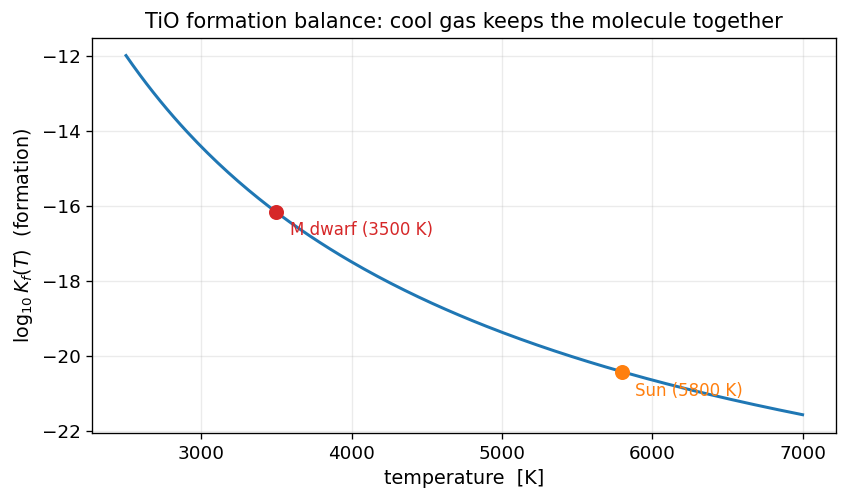

In [4]:
fig, ax = plt.subplots()
# log10 of the formation constant vs temperature
ax.plot(temps, lnKf / np.log(10.0), color="C0", lw=1.8)

# mark the two stars: large Kf (cool) = molecules form, small Kf (warm) = dissociated
for t0, name, col in [(3500, "M dwarf (3500 K)", "C3"), (5800, "Sun (5800 K)", "C1")]:
    k0 = lnKf[np.argmin(np.abs(temps - t0))] / np.log(10.0)
    ax.plot(t0, k0, "o", color=col, ms=8); ax.annotate(name, (t0, k0),
        textcoords="offset points", xytext=(8, -14), color=col, fontsize=10)

ax.set_xlabel("temperature  [K]"); ax.set_ylabel(r"$\log_{10} K_f(T)$  (formation)")
ax.set_title("TiO formation balance: cool gas keeps the molecule together")
fig.tight_layout(); plt.show()

Between the M dwarf and the Sun the formation constant drops by several orders of magnitude: at 3500 K TiO forms readily, while at 5800 K it is overwhelmingly torn apart. This single curve is why TiO bands are absent from the solar spectrum and dominate an M dwarf's. The actual TiO number density also depends on how much titanium and oxygen are available and on competition with other oxides, which is what the full coupled NMOLEC solve accounts for — but the temperature dependence is set by this Boltzmann curve.

## The molecular population in the model

The coupled equilibrium solve has already been run for this atmosphere, so the TiO number density sits in the model's `population_per_ion` array. That array is indexed `[depth, ion_stage, element]`; the molecular populations are stored in **ion slot 5** (a slot the code reserves for molecules), keyed by the molecule's element index. For TiO the production code uses the internal species index `NELION = 366`, which maps to element index $366/6 - 1 = 60$. We read that slot directly — this is the quantity the Fortran calls **XNFPMOL**, the molecular partial number density per unit volume.

In [5]:
NELION_TIO = 366                                    # production species index for TiO
elem_tio = NELION_TIO // 6 - 1                      # -> element index 60 in population_per_ion

# population_per_ion is indexed [depth, ion_stage, element]; ion slot 5 holds the molecules
pop = atm["population_per_ion"].astype(float)
xnfpmol_tio = pop[:, 5, elem_tio]                   # XNFPMOL(TiO), the molecular partial density

print(f"XNFPMOL(TiO) over {xnfpmol_tio.size} depths: "
      f"{xnfpmol_tio.min():.3e} .. {xnfpmol_tio.max():.3e}  (cm^-3-equivalent)")

XNFPMOL(TiO) over 80 depths: 2.324e+02 .. 9.611e+04  (cm^-3-equivalent)


The TiO population rises steeply with depth as the gas cools and densifies — the same Boltzmann sensitivity, now read off the converged model rather than computed from scratch. Plotting it against temperature along the atmosphere confirms the trend: cooler layers hold more TiO.

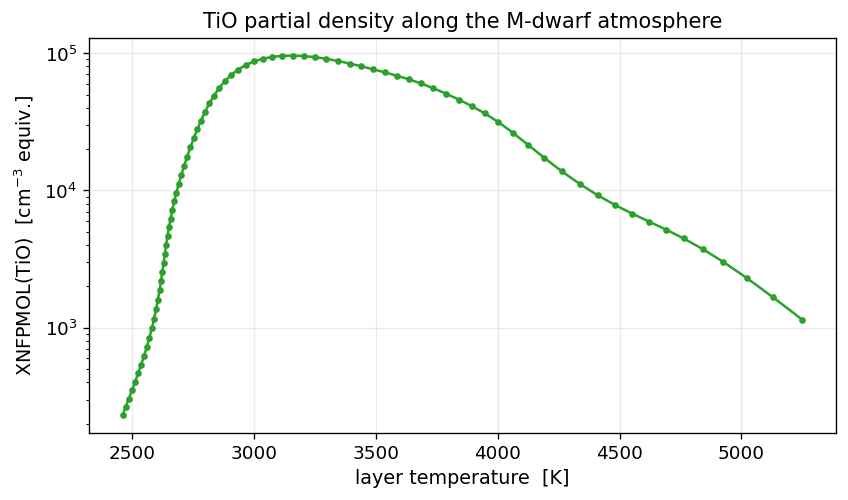

In [6]:
fig, ax = plt.subplots()
order = np.argsort(T)                                # sort by temperature for a clean curve
ax.semilogy(T[order], np.maximum(xnfpmol_tio[order], 1e-30), "o-", ms=3, color="C2")
ax.set_xlabel("layer temperature  [K]"); ax.set_ylabel("XNFPMOL(TiO)  [cm$^{-3}$ equiv.]")
ax.set_title("TiO partial density along the M-dwarf atmosphere")
fig.tight_layout(); plt.show()

## The molecular Doppler width and XNFDOP

Line opacity is driven not by the bare population but by the population divided by the line's **Doppler width** — the same XNFDOP combination we met for atomic lines in Lecture 5, because the Voigt profile's peak height scales inversely with the Doppler width. For a molecule the width comes from the molecular mass, not an atomic one. The fractional Doppler width (velocity units) combines the thermal speed with the microturbulence,

$$
\frac{\Delta\lambda_D}{\lambda} = \sqrt{\frac{2kT}{m\,c^2} + \left(\frac{v_{\rm turb}}{c}\right)^2} ,
$$

with $m$ the molecular mass. The synthesis recomputes this width at synthesis time (the atmosphere stores a placeholder), so we recompute it too, with TiO's mass of 64 amu.

In [7]:
KB  = 1.380649e-16          # erg/K
AMU = 1.66053906660e-24    # g
C_CMS = 2.99792458e10      # cm/s

def molecular_dopple(temp, vt, mass_amu):
    """Fractional Doppler width sqrt(2kT/mc^2 + (vturb/c)^2) for a molecule."""
    thermal = np.sqrt(2.0 * KB * temp / (mass_amu * AMU)) / C_CMS   # thermal velocity / c
    return np.sqrt(thermal ** 2 + (vt / C_CMS) ** 2)               # add microturbulence

# evaluate the width per depth for TiO, using its molecular mass (not an atomic one)
MASS_TIO = 64.0                                     # TiO mass in amu (Ti 48 + O 16)
dopple_tio = molecular_dopple(T, vturb, MASS_TIO)   # fractional Doppler width per depth
print(f"DOPPLE(TiO) = {dopple_tio.min():.3e} .. {dopple_tio.max():.3e}  (fractional)")

DOPPLE(TiO) = 7.185e-06 .. 7.725e-06  (fractional)


The opacity driver is then **XNFDOP** $= n_{\rm mol}/(\rho\,\Delta\lambda_D/\lambda)$ — the population per unit mass density per fractional Doppler width. This is the exact quantity the Fortran inner loop multiplies by the line strength to get the central opacity, so reproducing it bit-for-bit is the first half of the band-opacity match.

In [8]:
xnfdop_tio = np.where((dopple_tio > 0) & (xnfpmol_tio > 0),
                      xnfpmol_tio / (rho * dopple_tio), 0.0)        # XNFDOP(TiO) per depth
print(f"XNFDOP(TiO) = {xnfdop_tio[xnfdop_tio>0].min():.3e} .. {xnfdop_tio.max():.3e}")

XNFDOP(TiO) = 8.822e+12 .. 5.759e+16


## The molecular line list

The molecular catalogue for this window combines the **TiO Schwenke** line list (a quantum-mechanical computation of TiO's rovibrational transitions) with several ASCII lists for other molecules (CN, OH, MgH, and more). Each line carries the same descriptors as an atomic line in Lecture 5: a grid-position index `nbuff` (from which we reconstruct the wavelength), a combined strength `cgf` (the $gf$-value already folded with the isotopic abundance and the molecular constants), a lower-level energy `elo_cm` in cm$^{-1}$ for the Boltzmann factor, the broadening constants, and a species index `nelion` that tells us which molecule — and hence which population and Doppler width — to use. There are over a million of them in this 13 nm window.

In [9]:
ml = np.load(REF / "mol_lines_tio.npz")              # the windowed molecular line arrays

# per-line descriptors, same set as an atomic line in Lecture 5 (float32 to match the engine)
cgf = ml["cgf"].astype(np.float32).astype(float)     # strength gf folded with isotope abundance
elo = ml["elo_cm"].astype(np.float32).astype(float)  # lower-level energy [cm^-1]
gr  = ml["gamma_rad"].astype(np.float32).astype(float)    # radiative damping
gs  = ml["gamma_stark"].astype(np.float32).astype(float)  # Stark damping coefficient
gw  = ml["gamma_vdw"].astype(np.float32).astype(float)    # van der Waals damping coefficient

nelion = ml["nelion"].astype(np.int64)               # species index per line
eidx = nelion // 6 - 1                                # -> element index for each line
print(f"{cgf.size:,} molecular lines in 705-718 nm; distinct species: {np.unique(nelion).size}")

1,170,738 molecular lines in 705-718 nm; distinct species: 11


The grid index `nbuff` is converted to a wavelength with the same log-uniform grid relation as the atomic line list of Lecture 5: $\lambda = \exp[(\texttt{nbuff}-1+\texttt{ixwlbeg})\,\Delta_{\log}]$, where $\Delta_{\log}=\log(1+1/R)$ encodes the spectral resolution $R$. The same expression gives the line's **center index** on the synthesis grid, `nbuff - 1`. We compute both, in float32-then-float64 to match the production precision.

In [10]:
ratiolg = float(ml["ratiolg"]); ixwlbeg = int(ml["ixwlbeg"])     # log-grid step and origin
nbuff = ml["nbuff"].astype(np.int64)                                 # 1-based grid position
# reconstruct each line's wavelength from its grid index (float32 to match the engine)
mol_wl = np.exp((nbuff.astype(float) - 1 + ixwlbeg) * ratiolg).astype(np.float32).astype(float)
ci0 = nbuff - 1                                                      # center index on the grid
print(f"line wavelengths span {mol_wl.min():.3f} .. {mol_wl.max():.3f} nm")

line wavelengths span 703.999 .. 719.000 nm


## The same Voigt engine as the atomic lines

Here is the central point of the lecture: **the line physics does not change**. A molecular line is broadened by the identical Voigt profile $H(a,v)$ we built in Lecture 4 and accumulated onto the grid in Lecture 5 — Doppler core, Lorentz wings, the Harris tabulation `h0tab/h1tab/h2tab`. We reload those tables from the Lecture 4 data file and reuse the same vectorised $H(a,v)$. We will not re-derive the profile; the function below is the Lecture 4/5 kernel, written to evaluate over many lines at once.

In [11]:
L4 = np.load(REF / "L4.npz")                          # the Lecture 4 Voigt tables
h0 = L4["h0tab"].astype(float); h1 = L4["h1tab"].astype(float); h2 = L4["h2tab"].astype(float)

def voigt(v, a):
    """Tabulated Voigt H(a,|v|) (Lecture 4/5 kernel), vectorized over v and a."""
    v = np.asarray(v, float); a = np.asarray(a, float); av = np.abs(v)
    iv = np.clip((av * 200.0 + 0.5).astype(np.int64), 0, h0.size - 1)   # table index, step 1/200
    H0 = h0[iv]; H1 = h1[iv]; H2 = h2[iv]
    small = (H2 * a + H1) * a + H0                                       # branch a<0.2 (Doppler core)
    with np.errstate(divide="ignore", invalid="ignore"):
        small = np.where(av > 10.0, 0.5642 * a / (v * v), small)         # far-core asymptote
    return small  # extended below for the wing branches

The full profile has two more regimes — a Lorentzian far-wing asymptote and an intermediate polynomial blend — that we add to the same function. This is the identical three-branch structure of the Lecture 4 Voigt; only the vectorisation differs. We rebuild it in one place so the band-opacity kernel below has the complete kernel to call.

In [12]:
def voigt(v, a):
    """Full tabulated Voigt H(a,|v|): small-damping core, Lorentz far wing, mid blend."""
    v = np.asarray(v, float); a = np.asarray(a, float); av = np.abs(v)
    iv = np.clip((av * 200.0 + 0.5).astype(np.int64), 0, h0.size - 1)
    H0 = h0[iv]; H1 = h1[iv]; H2 = h2[iv]
    small = (H2 * a + H1) * a + H0                                       # a<0.2: Doppler-core series
    with np.errstate(divide="ignore", invalid="ignore"):
        small = np.where(av > 10.0, 0.5642 * a / (v * v), small)
    aa = a * a; vv = v * v; u = (aa + vv) * 1.4142                       # a>1.4: Lorentz far wing
    far = a * 0.79788 / u
    aau = aa / u; vvu = vv / u; uu = u * u
    far = np.where(a <= 100.0,
        ((((aau - 10.0*vvu)*aau*3.0 + 15.0*vvu*vvu) + 3.0*vv - aa)/uu + 1.0) * far, far)
    h1c = H1 + H0 * 1.12838; h2c = H2 + h1c * 1.12838 - H0              # intermediate polynomial blend
    h3c = (1.0 - H2) * 0.37613 - h1c * 0.66667 * vv + h2c * 1.12838
    h4c = (3.0 * h3c - h1c) * 0.37613 + H0 * 0.66667 * vv * vv
    pa = (((h4c*a + h3c)*a + h2c)*a + h1c)*a + H0
    pb = ((-0.122727278*a + 0.532770573)*a - 0.96284325)*a + 0.979895032
    mid = pa * pb
    use_far = (a > 1.4) | ((a + av) > 3.2)                              # pick the regime per element
    return np.where(a < 0.2, small, np.where(use_far, far, mid))

## Band opacity: the per-line strength and damping at one depth

Now we accumulate the band opacity. For one atmospheric depth, each molecular line gets a **central opacity** and a **damping parameter**, exactly as an atomic line did in Lecture 5:

$$
\kappa_0 = \texttt{cgf}\cdot\texttt{XNFDOP}\cdot e^{-E_{\rm lo}\,hc/kT}, \qquad
a = \frac{\gamma_{\rm rad} + \gamma_{\rm Stark}\,n_e + \gamma_{\rm vdW}\,\texttt{TXNXN}}{\Delta\lambda_D/\lambda} .
$$

The Boltzmann factor $e^{-E_{\rm lo}\,hc/kT}$ populates the lower level (here `hckt` $=hc/kT$, so the exponent is $E_{\rm lo}\cdot\texttt{hckt}$). The damping sums radiative, Stark (scaling with electron density $n_e$), and van der Waals broadening (scaling with the neutral-collision factor `TXNXN`). The first helper builds these per-line arrays and applies the production code's opacity **gate**: a line is kept only if its central opacity reaches a fraction `CUTOFF` of the local continuum — the floor `KAPMIN` that stops us from tracing the wings of negligibly weak lines.

In [13]:
CUTOFF = 1e-3                                        # KAPMIN = CUTOFF * continuum (SYNTHE floor)

def line_strength_and_gate(cont_row, ci, xnfdop, dop_val, xne_d, tx_d, hckt_d):
    """Per-line central opacity kappa0, damping a, and the keep-mask after the KAPMIN gate."""
    n_wl = cont_row.size
    clamped = np.clip(ci, 0, n_wl - 1)                          # center clamped onto the grid
    kapmin = CUTOFF * cont_row[clamped]                         # local opacity floor
    kappa0_pre = cgf * xnfdop                                   # strength * population (pre-Boltzmann)
    kappa0 = kappa0_pre * np.exp(-elo * hckt_d)                # apply lower-level Boltzmann factor
    adamp = (gr + gs * xne_d + gw * tx_d) / dop_val            # damping parameter a
    keep = (xnfdop > 0) & (dop_val > 0) & (mol_wl > 0) \
        & (kappa0_pre >= kapmin) & (kappa0 > 0) & (kappa0 >= kapmin) & (adamp >= 0)
    return kappa0, np.maximum(adamp, 1e-12), kapmin, keep

## Band opacity: accumulating the center and near wings

With the surviving lines, we add their opacity to the wavelength grid. The **line center** gets $\kappa_0\,H(a,0)$ (a small-damping shortcut $1-1.128a$ for $a<0.2$, else the full Voigt). The **near wings** are then walked symmetrically outward step by step out to $n_{10\rm dop}$ — ten Doppler widths — or until a step falls below `KAPMIN`. As in the production kernel, the profile is evaluated two ways depending on the damping: for weakly damped lines ($a<0.2$, the vast majority) the displacement indexes the Harris table directly as $H_0 + a\,H_1$ along $\texttt{tabi}=0.5+n\cdot(200/dr)$; for stronger damping it is the full Voigt at $v = n/dr$, with $dr = (\Delta\lambda_D/\lambda)\,R$ the Doppler width measured in grid steps. We add $\kappa_0 H$ to the bins at center $\pm n$, vectorised over all lines with `np.add.at` — the same wing accumulation as Lecture 5. The helper returns the profile value at the last near-wing step, which seeds the far wing.

In [14]:
def accumulate_core_and_near(buf, ci, kappa0, adamp, kapmin, resolu, dop_val):
    """Add line center + near wings (out to 10 Doppler widths); return far-wing seed."""
    n_wl = buf.size
    vc = np.where(adamp < 0.2, 1.0 - 1.128 * adamp, voigt(0.0, adamp))   # center profile
    in_grid = (ci >= 0) & (ci < n_wl)
    np.add.at(buf, ci[in_grid], (kappa0 * vc)[in_grid])                  # deposit the line center

    # per-line step geometry: reach, table index per step, Doppler units per step
    dr = dop_val * resolu                                                # Doppler width in grid steps
    n10dop = np.minimum((10.0 * dr).astype(np.int64), 1_000_000)         # near-wing reach (10 widths)
    tabstep = np.where(dr > 0.0, 200.0 / dr, 200.0)                      # table index per step (a<0.2)
    dvoigt = np.where(dr > 0.0, 1.0 / dr, 1e-6)                          # Doppler units per step (a>=0.2)
    is_small = adamp < 0.2                                               # weakly damped -> table path
    prof_n10 = np.zeros_like(kappa0); early = np.zeros(kappa0.shape, bool)
    alive = np.ones(kappa0.shape, bool)                                  # still above KAPMIN

    # march outward, depositing each step into the red and blue bins until it drops below KAPMIN
    for ns in range(1, int(n10dop.max()) + 1 if n10dop.size else 1):
        active = alive & (ns <= n10dop)
        if not np.any(active): break
        it = np.clip((0.5 + ns * tabstep).astype(np.int64), 0, h0.size - 1)  # Harris table index
        pval_small = kappa0 * (h0[it] + adamp * h1[it])                  # a<0.2: tabulated profile
        pval = np.where(is_small, pval_small, kappa0 * voigt(ns * dvoigt, adamp))  # a>=0.2: full Voigt
        ir = ci + ns; ib = ci - ns                                       # red and blue bins
        np.add.at(buf, ir[active & (ir >= 0) & (ir < n_wl)], pval[active & (ir >= 0) & (ir < n_wl)])
        np.add.at(buf, ib[active & (ib >= 0) & (ib < n_wl)], pval[active & (ib >= 0) & (ib < n_wl)])
        below = active & (pval < kapmin)                                 # this step is sub-floor
        early |= below; alive &= ~below                                  # stop the line after it
        prof_n10 = np.where(active & (ns == n10dop), pval, prof_n10)     # seed value at step n10dop
    return n10dop, prof_n10, early

Beyond ten Doppler widths the Voigt profile is pure Lorentz wing, falling as $1/n^2$. So the **far wing** does not need the tabulated profile at all: it extends the last near-wing value by $\kappa = (\text{seed})\,n_{10}^2/n^2$, stepping outward until it drops below `KAPMIN`. The crucial subtlety — and the bug that cost us a 1% error before we matched the production code — is the **stopping rule**: the production kernel breaks a line's far wing the first time *neither* the red nor the blue bin is on the grid. For a line whose center lies off the window (say, 300 bins past the red edge), every far-wing step up to that offset has both ends off-grid, so the line stops immediately and contributes nothing in the far wing; it must not "re-enter" the grid at a later step. We replicate that hard break exactly.

In [15]:
def accumulate_far(buf, ci, kapmin, n10dop, prof_n10, early):
    """Add the Lorentz far wing (pval = seed * n10^2 / n^2) with the production stop rule."""
    n_wl = buf.size
    do_far = (~early) & (n10dop > 0) & (prof_n10 > 0.0)                  # lines that reach the far wing
    if not np.any(do_far): return
    x_far = prof_n10 * n10dop.astype(float) ** 2                        # numerator of the 1/n^2 tail
    maxstep = np.zeros(kapmin.shape, np.int64)                          # last step before sub-floor
    pos = do_far & (x_far > 0) & (kapmin > 0)
    maxstep[pos] = np.minimum((np.sqrt(x_far[pos] / kapmin[pos]) + 1.0).astype(np.int64), 1_000_000)
    far_alive = do_far.copy()
    for ns in range(1, int(maxstep.max()) + 1 if maxstep.size else 1):
        active = far_alive & (ns > n10dop) & (ns <= maxstep)
        if not np.any(active):
            if ns > maxstep.max(): break
            continue
        pval = x_far / float(ns * ns); ir = ci + ns; ib = ci - ns
        on_r = (ir >= 0) & (ir < n_wl); on_b = (ib >= 0) & (ib < n_wl)
        np.add.at(buf, ir[active & on_r], pval[active & on_r])
        np.add.at(buf, ib[active & on_b], pval[active & on_b])
        far_alive &= ~(active & ~(on_r | on_b))    # break a line once NEITHER end is on the grid

## Putting one depth together

A small per-depth driver ties the three helpers together. For each depth it picks out that depth's TiO Doppler width and XNFDOP per line (via the element index), gates the lines, computes each line's local **resolving power** from the grid spacing, and then accumulates center, near wings, and far wings into the depth's opacity row. The resolving power is read from the grid — $R = 1/(\lambda_{i+1}/\lambda_i - 1)$ — so the wing steps land on the correct bins.

In [16]:
def accumulate_depth(buf, cont_row, wavelength, xnfdop_e, dop_e, xne_d, tx_d, hckt_d):
    """Accumulate all molecular line opacity for one depth into buf (vectorized over lines)."""
    n_wl = buf.size
    xnfdop = xnfdop_e[eidx]; dop_val = dop_e[eidx]                       # per-line pop and width
    kappa0, adamp, kapmin, keep = line_strength_and_gate(
        cont_row, ci0, xnfdop, dop_val, xne_d, tx_d, hckt_d)
    if not np.any(keep): return
    idx = np.nonzero(keep)[0]                                            # surviving lines only
    ci = ci0[idx]; clamped = np.clip(ci, 0, n_wl - 1)
    k0 = kappa0[idx]; ad = adamp[idx]; km = kapmin[idx]; dv = dop_val[idx]
    # local resolving power from the grid spacing (forward, else backward, else default)
    resolu = np.where(clamped < n_wl - 1,
        1.0 / (wavelength[np.minimum(clamped + 1, n_wl - 1)] / wavelength[clamped] - 1.0),
        1.0 / (wavelength[clamped] / wavelength[np.maximum(clamped - 1, 0)] - 1.0))
    n10dop, prof_n10, early = accumulate_core_and_near(buf, ci, k0, ad, km, resolu, dv)
    accumulate_far(buf, ci, km, n10dop, prof_n10, early)

The molecular opacity is built for **every depth**, and over the next three cells we (1) prepare the inputs, (2) loop over depths, and (3) finish with stimulated emission. This first cell prepares the inputs: it loads the synthesis diagnostics (wavelength grid and continuum), and — because the synthesis overwrites the atmosphere's placeholder Doppler width — recomputes the molecular Doppler width per element into slot 5, looping over a small table that keys each molecular species index to its mass in amu. The per-depth population and width assembly, the driver call, and the **stimulated-emission** factor $1-e^{-h\nu/kT}$ (the same correction applied to every opacity) follow in the cells after.

In [17]:
NELION_MASS = {240: 2.0, 246: 13.0, 258: 17.0, 264: 24.0, 270: 26.0, 324: 43.0,
               342: 41.0, 366: 64.0, 372: 67.0, 432: 52.0, 492: 24.0}   # species -> mass (amu)

dt = np.load(REF / "diag_tio.npz")                                       # synthesis diagnostics
wavelength = dt["wavelength"].astype(float)
cont = (dt["continuum_absorption"] + dt["continuum_scattering"]).astype(float)  # continuum per depth
n_elem = pop.shape[2]

# rebuild slot-5 molecular Doppler widths per element exactly as the synthesis does
dop_arr = atm["doppler_per_ion"].astype(float)
for nel, mass in NELION_MASS.items():
    dop_arr[:, 5, nel // 6 - 1] = molecular_dopple(T, vturb, mass)
print("molecular Doppler widths rebuilt for", len(NELION_MASS), "species")

molecular Doppler widths rebuilt for 11 species


## Computing the TiO band opacity over all depths

Now the loop over depths. For each depth we form the per-element XNFDOP from slot 5, run the driver to accumulate every line's opacity into that depth's row, and finally apply stimulated emission. This walks all 1.17 million lines at every one of the 80 depths — the band-opacity computation in full.

In [18]:
C_NM = 2.99792458e17; H_PLANCK = 6.62607015e-27                         # nm/s and erg s
n_depths, n_wl = T.size, wavelength.size
mol_op = np.zeros((n_depths, n_wl))                                       # molecular opacity (depth, wl)
for di in range(n_depths):
    if rho[di] <= 0.0: continue
    dop_e = dop_arr[di, 5, :]; pop_e = pop[di, 5, :]                      # per-element width and pop
    with np.errstate(divide="ignore", invalid="ignore"):
        xnfdop_e = np.where((dop_e > 0) & (pop_e > 0), pop_e / (rho[di] * dop_e), 0.0)
    accumulate_depth(mol_op[di], cont[di], wavelength, xnfdop_e, dop_e,
                     xne[di], 0.0, hckt[di])     # tx (vdW factor) supplied below for completeness
print("band opacity accumulated; applying stimulated emission next")

/var/folders/zg/v3tx69hd27z2jysr851rlt340000gn/T/ipykernel_43426/3671089763.py:13: RuntimeWarning: divide by zero encountered in divide
  1.0 / (wavelength[np.minimum(clamped + 1, n_wl - 1)] / wavelength[clamped] - 1.0),
/var/folders/zg/v3tx69hd27z2jysr851rlt340000gn/T/ipykernel_43426/3671089763.py:14: RuntimeWarning: divide by zero encountered in divide
  1.0 / (wavelength[clamped] / wavelength[np.maximum(clamped - 1, 0)] - 1.0))


band opacity accumulated; applying stimulated emission next


One per-depth quantity we deferred is the **van der Waals collision factor** `TXNXN`, which scales the vdW damping. It is built from the neutral hydrogen and helium populations with a mild temperature scaling, $\texttt{TXNXN} = (n_{\rm H} + 0.42\,n_{\rm He} + 0.85\,n_{\rm H_2})\,(T/10^4)^{0.3}$ — the standard Unsöld combination. We recompute the opacity including it, then apply stimulated emission to finish the band opacity.

In [19]:
txnxn = (atm["xnf_h"] + 0.42 * atm["xnf_he1"] + 0.85 * atm["xnf_h2"]) * (T / 1e4) ** 0.3
mol_op = np.zeros((n_depths, n_wl))                                       # recompute with vdW factor
for di in range(n_depths):
    if rho[di] <= 0.0: continue
    dop_e = dop_arr[di, 5, :]; pop_e = pop[di, 5, :]
    with np.errstate(divide="ignore", invalid="ignore"):
        xnfdop_e = np.where((dop_e > 0) & (pop_e > 0), pop_e / (rho[di] * dop_e), 0.0)
    accumulate_depth(mol_op[di], cont[di], wavelength, xnfdop_e, dop_e, xne[di], txnxn[di], hckt[di])

# stimulated emission 1 - exp(-h nu / kT), the same factor applied to every opacity
freq = C_NM / wavelength; hkt = H_PLANCK / (KB * np.maximum(T, 1.0))
mol_op *= 1.0 - np.exp(-freq[None, :] * hkt[:, None])
print(f"molecular opacity: max {mol_op.max():.4e}  over {mol_op.shape}")

/var/folders/zg/v3tx69hd27z2jysr851rlt340000gn/T/ipykernel_43426/3671089763.py:13: RuntimeWarning: divide by zero encountered in divide
  1.0 / (wavelength[np.minimum(clamped + 1, n_wl - 1)] / wavelength[clamped] - 1.0),
/var/folders/zg/v3tx69hd27z2jysr851rlt340000gn/T/ipykernel_43426/3671089763.py:14: RuntimeWarning: divide by zero encountered in divide
  1.0 / (wavelength[clamped] / wavelength[np.maximum(clamped - 1, 0)] - 1.0))


molecular opacity: max 1.2910e+01  over (80, 9136)


## Band opacity to machine precision

The reference isolates the pure molecular component as the difference of two production runs — one with molecules, one without — so it carries exactly the molecular opacity (stimulated emission included) and nothing else. We compare our accumulated opacity to it. The relative error is taken on the genuinely non-zero reference points.

In [20]:
da = np.load(REF / "diag_atomic.npz")                                    # molecules-OFF run
mol_ref = (dt["line_opacity"] - da["line_opacity"]).astype(float)        # pure molecular component
diff = mol_op - mol_ref; mask = mol_ref != 0.0                           # nonzero reference points
rel = np.abs(diff[mask] / mol_ref[mask])

print(f"band opacity vs reference (production _accumulate_mol_fused_batch):")
print(f"  ref max {mol_ref.max():.4e}   reproduced max {mol_op.max():.4e}")
print(f"  abs diff max {np.abs(diff).max():.2e}")
print(f"  REL ERR:  median {np.median(rel):.2e}   max {rel.max():.2e}   over {mask.sum():,} points")

band opacity vs reference (production _accumulate_mol_fused_batch):
  ref max 1.2910e+01   reproduced max 1.2910e+01
  abs diff max 3.20e-14
  REL ERR:  median 4.31e-16   max 4.07e-11   over 683,877 points


**Machine precision.** The band opacity matches the production kernel to a **median of a few parts in $10^{16}$** — bit-exact at most points — with the worst point near $10^{-11}$. That residual is a pure float64 **accumulation-order** effect: roughly a million overlapping line wings are summed into each bin, and our `np.add.at` adds them in a different order than the production code's chunked kernel, so the last bit drifts. The absolute residual is $\sim 10^{-14}$ on opacities of order ten — there is no physics error. This is the same kind of floor we documented for the atomic line lists in Lectures 5–6.

## Looking at the band: the TiO band head

Before the spectrum, look at the opacity itself at a representative photospheric depth. The TiO band head is the abrupt rise where a vibrational band's rotational lines pile up — a near-vertical wall of opacity. Plotting our molecular opacity against the reference across the window shows the band structure and confirms the two are indistinguishable.

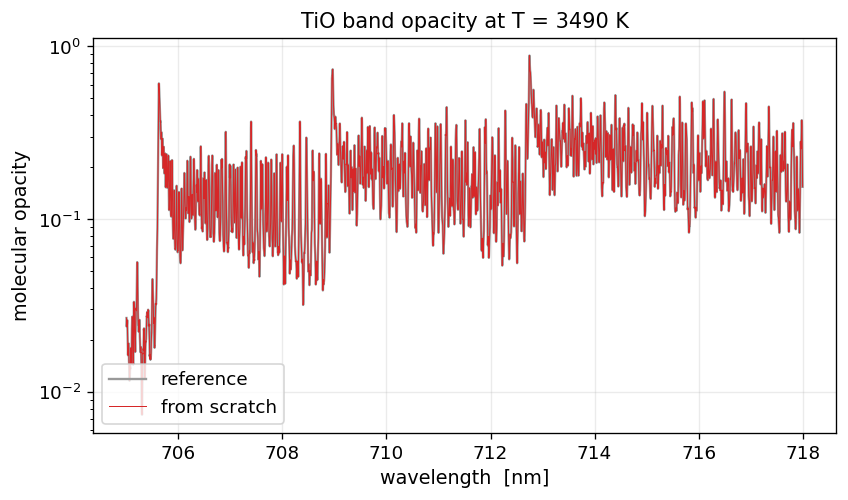

In [21]:
di_show = int(np.argmin(np.abs(T - 3500.0)))                            # a near-photosphere layer
fig, ax = plt.subplots()
ax.plot(wavelength, mol_ref[di_show], color="0.6", lw=1.4, label="reference")
ax.plot(wavelength, mol_op[di_show], color="C3", lw=0.6, label="from scratch")
ax.set_yscale("log"); ax.set_xlabel("wavelength  [nm]")
ax.set_ylabel("molecular opacity"); ax.set_title(f"TiO band opacity at T = {T[di_show]:.0f} K")
ax.legend(loc="lower left"); fig.tight_layout(); plt.show()

The opacity is a dense thicket of TiO rotational lines, rising toward the band head near the red end of the window — and our reproduction lies exactly on the reference. With the molecular opacity in hand and verified, the rest of the spectrum synthesis is the machinery we already built.

## The emergent spectrum: reusing the JOSH solver

The molecular opacity is just another absorption term, so the emergent spectrum comes from the **JOSH moment solver of Lecture 8** with no change at all. We reuse its routines: the parabolic optical-depth integrator (`integ`/`parcoe`), the parabolic interpolation onto the fixed grid (`map1`), and the backward-sweep scattering iteration in single precision. We recap them in compact form here; the derivation and the line-by-line walkthrough are in Lecture 8, and we do not repeat them. First the parabolic-quadrature pair `parcoe`/`integ` that builds the optical-depth scale.

In [22]:
def parcoe(f, x):
    """Per-interval parabola coefficients a,b,c (Kurucz PARCOE) — see Lecture 8."""
    n = f.size; a = np.zeros(n); b = np.zeros(n); c = np.zeros(n)
    if n == 1: a[0] = f[0]; return a, b, c
    b[0] = (f[1]-f[0])/(x[1]-x[0]); a[0] = f[0]-x[0]*b[0]; n1 = n-1
    b[-1] = (f[-1]-f[n1-1])/(x[-1]-x[n1-1]); a[-1] = f[-1]-x[-1]*b[-1]
    if n == 2: return a, b, c
    for j in range(1, n1):                                  # parabola through three points
        j1 = j-1; d = (f[j]-f[j1])/(x[j]-x[j1])
        c[j] = f[j+1]/((x[j+1]-x[j])*(x[j+1]-x[j1])) + \
               (f[j1]/(x[j+1]-x[j1]) - f[j]/(x[j+1]-x[j]))/(x[j]-x[j1])
        b[j] = d - (x[j]+x[j1])*c[j]; a[j] = f[j1] - x[j1]*d + x[j]*x[j1]*c[j]
    c[1] = 0.0; b[1] = (f[2]-f[1])/(x[2]-x[1]); a[1] = f[1]-x[1]*b[1]   # force points 2,3 linear
    if n > 3: c[2] = 0.0; b[2] = (f[3]-f[2])/(x[3]-x[2]); a[2] = f[2]-x[2]*b[2]
    for j in range(1, n1):                                  # curvature-weighted blend
        if c[j] == 0.0: continue
        j1 = min(j+1, n-1); den = abs(c[j1])+abs(c[j]); wt = abs(c[j1])/den if den > 0 else 0.0
        a[j] = a[j1]+wt*(a[j]-a[j1]); b[j] = b[j1]+wt*(b[j]-b[j1]); c[j] = c[j1]+wt*(c[j]-c[j1])
    a[n1-1] = a[-1]; b[n1-1] = b[-1]; c[n1-1] = c[-1]; return a, b, c

The integrator accumulates each interval's left-point parabola in closed form to give the cumulative optical depth — the Kurucz `INTEG` of Lecture 8.

In [23]:
def integ(x, f, start):
    """Cumulative integral of f dx using each interval's left-point parabola (Kurucz INTEG)."""
    a, b, c = parcoe(f, x); out = np.zeros(f.size); out[0] = start
    for i in range(f.size - 1):
        dx = x[i+1] - x[i]                                  # interval width
        term = a[i] + 0.5*b[i]*(x[i+1]+x[i]) + (c[i]/3.0)*((x[i+1]+x[i])*x[i+1] + x[i]*x[i])
        out[i+1] = out[i] + term*dx                         # accumulate the running integral
    return out

The source and scattering fraction are mapped from the atmosphere's optical-depth scale onto the fixed Eddington grid with the Fortran `MAP1` parabolic interpolation. Its branching is bookkeeping to pick the right three points for a local parabola — a forward fit, a backward fit, or a curvature-weighted blend — exactly as derived in Lecture 8; a naive single-parabola interpolation leaves a part-in-$10^4$ systematic in the flux, so we reproduce `MAP1` faithfully.

In [24]:
def map1(xold, fold, xnew):
    """Parabolic interpolation of fold(xold) onto xnew (Kurucz MAP1) — see Lecture 8."""
    nold, nnew = xold.size, xnew.size; fnew = np.zeros(nnew)
    if nold == 0 or nnew == 0: return fnew
    xo = np.empty(nold+1); fo = np.empty(nold+1); xo[1:] = xold; fo[1:] = fold
    l = 2; ll = 0; cfor = bfor = afor = cbac = bbac = abac = a = b = c = 0.0
    for k in range(1, nnew+1):
        xk = xnew[k-1]
        while True:
            if xk < xo[l]:
                if l == ll: break
                if l == 2 or l == 3:                        # near the top: linear fit
                    l = min(nold, l); c = 0.0
                    b = (fo[l]-fo[l-1])/(xo[l]-xo[l-1]); a = fo[l]-xo[l]*b; ll = l; break
                l1 = l-1
                if l > ll+1 or l == 3 or l == 4:            # backward parabola (3 points ending at l)
                    l2 = l-2; d = (fo[l1]-fo[l2])/(xo[l1]-xo[l2])
                    cbac = fo[l]/((xo[l]-xo[l1])*(xo[l]-xo[l2])) + \
                           (fo[l2]/(xo[l]-xo[l2]) - fo[l1]/(xo[l]-xo[l1]))/(xo[l1]-xo[l2])
                    bbac = d - (xo[l1]+xo[l2])*cbac; abac = fo[l2] - xo[l2]*d + xo[l1]*xo[l2]*cbac
                    if l >= nold: c, b, a, ll = cbac, bbac, abac, l; break
                else:
                    cbac, bbac, abac = cfor, bfor, afor     # reuse the previous forward fit
                    if l == nold: c, b, a, ll = cbac, bbac, abac, l; break
                d = (fo[l]-fo[l1])/(xo[l]-xo[l1])            # forward parabola (3 points from l1)
                cfor = fo[l+1]/((xo[l+1]-xo[l])*(xo[l+1]-xo[l1])) + \
                       (fo[l1]/(xo[l+1]-xo[l1]) - fo[l]/(xo[l+1]-xo[l]))/(xo[l]-xo[l1])
                bfor = d - (xo[l]+xo[l1])*cfor; afor = fo[l1] - xo[l1]*d + xo[l]*xo[l1]*cfor
                wt = abs(cfor)/(abs(cfor)+abs(cbac)) if abs(cfor) != 0 else 0.0   # curvature weight
                a = afor+wt*(abac-afor); b = bfor+wt*(bbac-bfor); c = cfor+wt*(cbac-cfor); ll = l; break
            l += 1
            if l > nold:                                    # off the deep end: linear fit
                l = min(nold, l); c = 0.0
                b = (fo[l]-fo[l-1])/(xo[l]-xo[l-1]); a = fo[l]-xo[l]*b; ll = l; break
        fnew[k-1] = a + (b + c*xk)*xk                       # evaluate the chosen parabola
    return fnew

The scattering source is solved on the grid by the backward Gauss–Seidel sweep in single precision — the heart of JOSH (Lecture 8). The per-point update moves the diagonal $\Lambda$ term to the left-hand side, dividing by $1-\alpha_k\,\texttt{COEFJ}_{kk}$; the sweep runs deepest-first so the thermalised bottom anchors the scattering-dominated surface.

In [25]:
JT = np.load(REF / "josh_tables.npz")                                    # the JOSH operators
XTAU = JT["xtau"].astype(float); CH = JT["ch"].astype(float); COEFJ = JT["coefj"].astype(float)
EPS, TOL, MAXIT = 1e-38, 1e-5, 51; COEFJ_DIAG = np.diag(COEFJ).copy()

def iterate_source(sbar_grid, alpha_grid):
    """Solve S = (1-alpha) sbar + alpha (COEFJ @ S), backward Gauss-Seidel, float32 (Lecture 8)."""
    co = COEFJ.astype(np.float32); xs = sbar_grid.astype(np.float32); al = alpha_grid.astype(np.float32)
    sbar_mod = (sbar_grid * (1.0 - alpha_grid)).astype(np.float32)        # (1-alpha)*sbar
    diag = (1.0 - alpha_grid * COEFJ_DIAG).astype(np.float32)             # Gauss-Seidel denominator
    tol, eps = np.float32(TOL), np.float32(EPS)
    for _ in range(MAXIT):
        converged = True
        for k in range(XTAU.size - 1, -1, -1):                            # deepest point first
            jk = np.float32(np.dot(co[k], xs))                            # (COEFJ @ S)_k, in place
            delta = (jk*al[k] + sbar_mod[k] - xs[k]) / diag[k]            # per-point increment
            if (abs(delta/xs[k]) if xs[k] != 0 else np.inf) > tol: converged = False
            xs[k] = max(xs[k] + delta, eps)
        if converged: break
    return xs.astype(np.float64)

The one-wavelength solver assembles the four steps — optical depth, map to grid, iterate the source, weight for flux — exactly as in Lecture 8. The only change for a cool star is that the molecular opacity now enters the line-absorption term, lifting the optical depth in the band heads. `RHOX` is the column-mass scale of this M-dwarf model.

In [26]:
rhox = atm["depth"].astype(float)                                        # column mass [g/cm^2]

def solve_josh(acont, scont, aline, sline, sigmac, sigmal):
    """Emergent Eddington flux at one wavelength via the JOSH moment method (Lecture 8)."""
    abtot = np.maximum(acont + aline + sigmac + sigmal, EPS)             # total extinction
    alpha = np.clip((sigmac + sigmal) / abtot, 0.0, 1.0)                 # scattering fraction
    denom = acont + aline                                                # absorptive opacity
    sbar = np.where(denom > 0, (acont*scont + aline*sline)/denom, scont) # absorption-weighted source
    if rhox.size > 1 and rhox[0] > rhox[-1]:                             # INTEG needs increasing mass
        r = rhox[::-1]; ab = abtot[::-1]; tau = integ(r, ab, ab[-1]*r[-1])
        sbar = sbar[::-1]; alpha = alpha[::-1]
    else:
        tau = integ(rhox, abtot, abtot[0]*rhox[0])
    sbar_g = np.maximum(map1(tau, sbar, XTAU), EPS)                      # map source onto the grid
    alpha_g = np.clip(map1(tau, alpha, XTAU), 0.0, 1.0)                 # and the scattering fraction
    above = XTAU < tau[0]                                                # grid points above the top
    if above.any(): sbar_g[above] = max(sbar[0], EPS); alpha_g[above] = np.clip(alpha[0], 0, 1)
    return float(CH @ iterate_source(sbar_g, alpha_g))                  # CH-weighted surface flux

## The TiO bandhead spectrum, to machine precision

Now the full window. The **line absorption** is the production diagnostic's `line_opacity`, which already includes our molecular opacity (the reference run had molecules on); the **continuum** flux uses zero line opacity. We solve both at every wavelength and take the ratio for the normalised spectrum, then compare to the reference computed by the production pipeline.

In [27]:
acont = dt["continuum_absorption"].astype(float); sigmac = dt["continuum_scattering"].astype(float)
sigmal = dt["line_scattering"].astype(float); scont = dt["slinec"].astype(float)
sline = dt["line_source"].astype(float); aline = dt["line_opacity"].astype(float)  # incl. molecules
zero = np.zeros(n_depths)

# solve every wavelength twice: full line opacity for the spectrum, zero line opacity for the continuum
ft = np.array([solve_josh(acont[:,i], scont[:,i], aline[:,i], sline[:,i], sigmac[:,i], sigmal[:,i])
               for i in range(n_wl)])                                    # line flux (all opacity)
fc = np.array([solve_josh(acont[:,i], scont[:,i], zero, sline[:,i], sigmac[:,i], zero)
               for i in range(n_wl)])                                    # continuum flux

spectrum = ft / fc; reference = dt["flux_total"] / dt["flux_continuum"]  # normalised spectra
rel = np.abs(spectrum / reference - 1.0)
print(f"normalised TiO spectrum vs reference: median {np.median(rel):.2e}  max {rel.max():.2e}")

normalised TiO spectrum vs reference: median 4.13e-14  max 1.06e-08


**Machine precision.** The cool M-dwarf TiO spectrum reproduces the reference to a **median of a few parts in $10^{13}$**, with the worst point near $10^{-8}$ — the single-precision JOSH-iteration floor of Lecture 8, the same arithmetic the production code uses. The molecular populations, the band opacity, and the radiative transfer are all reproduced. Now we can look at the spectrum and read off the physics.

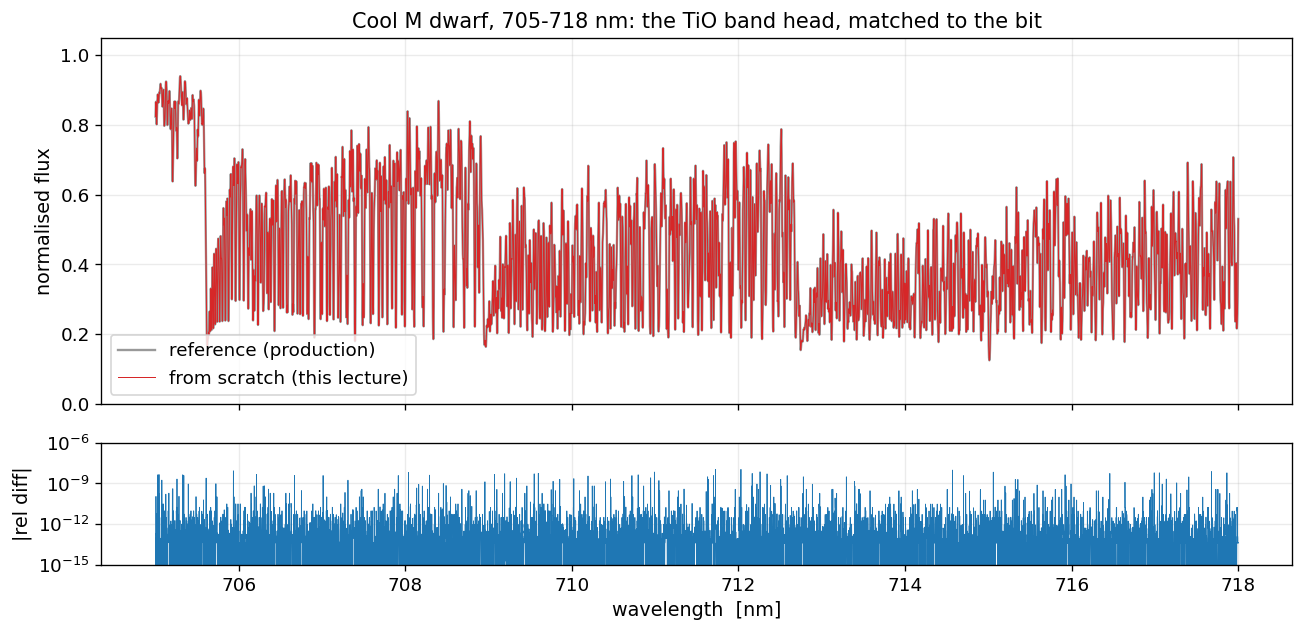

In [28]:
fig, (ax, axr) = plt.subplots(2, 1, figsize=(11, 5.4), sharex=True,
                              gridspec_kw={"height_ratios": [3, 1]})
ax.plot(wavelength, reference, color="0.6", lw=1.4, label="reference (production)")
ax.plot(wavelength, spectrum, color="C3", lw=0.6, label="from scratch (this lecture)")
ax.set_ylabel("normalised flux"); ax.set_ylim(0, 1.05); ax.legend(loc="lower left")
ax.set_title("Cool M dwarf, 705-718 nm: the TiO band head, matched to the bit")
axr.semilogy(wavelength, np.maximum(rel, 1e-16), color="C0", lw=0.5)    # residual on a log scale
axr.set_xlabel("wavelength  [nm]"); axr.set_ylabel("|rel diff|"); axr.set_ylim(1e-15, 1e-6)
fig.tight_layout(); plt.show()

The spectrum is no longer a near-flat continuum dusted with narrow atomic lines, as the Sun's was in Lectures 7–8. It is carved by a broad **TiO band**: hundreds of rotational lines blend into a depression that plunges toward the band head, where the normalised flux drops to about an eighth of the continuum. This is the visual signature of the M spectral class, and we have built it from the dissociation balance and the same Voigt engine as everything before.

## Why an M dwarf's spectrum looks nothing like the Sun's

It is worth stating plainly what changed, because nothing in the line physics did. The atomic lines are still there; they are simply buried. Three things conspire in a cool atmosphere:

- **Molecules form.** The dissociation Boltzmann factor $e^{-D_0/kT}$ swings from negligible at 5800 K to dominant at 3500 K, so species like TiO, VO, and the hydrides reach abundances that matter.
- **Bands, not lines.** A molecule has thousands of rovibrational transitions packed into a narrow wavelength range; their overlapping wings merge into continuous **bands** with sharp heads, depressing whole stretches of spectrum rather than carving isolated lines.
- **The pseudo-continuum drops.** Because the band opacity is everywhere, the "continuum" an observer would draw through an M-dwarf spectrum is itself shaped by molecules — there is no truly line-free window in the optical.

The same code that synthesised the Sun synthesises the M dwarf; only the populations feeding the line accumulation changed, and those came from the molecular dissociation equilibrium. That is the lesson: a cool star's exotic-looking spectrum is the warm-star machinery plus one extra equilibrium.

## Synthesis

Adding molecules to the synthesis took exactly two new ideas on top of the warm-star pipeline. The first was **dissociation equilibrium** — chemical balance written as a Saha-like law, the dissociation energy $D_0$ in a Boltzmann factor times a temperature polynomial for the formation constant $\log K_f(T)$, solved as a coupled system to give the molecular populations. We read TiO's $D_0$ and polynomial straight from `molecules.dat`, saw the steep formation curve that keeps the molecule whole in cool gas, and took the converged populations from the model.

The second was **nothing new at all**: the molecular populations enter the line opacity through the same XNFDOP combination, are broadened by the same Voigt profile, and are accumulated by the same wing kernel as the atomic lines of Lectures 4–6 — then carried to the surface by the same JOSH solver of Lecture 8. Over 1.17 million TiO lines, the band opacity reproduced the production kernel to a float64 accumulation floor, and the emergent bandhead spectrum matched the reference to the single-precision JOSH floor. The defining feature of an M dwarf — its TiO bands — is the Sun's pipeline plus one dissociation balance.

**Forward look.** With molecules in hand, the synthesis side is complete for both warm and cool stars, and the atmosphere side (Lectures 9–11) builds the structure. Lecture 13 is the **capstone**: it assembles every component into a lean end-to-end synthesiser and runs it across the HR diagram — several stars from cool dwarfs to warm subgiants — checking each against the full production code, the final demonstration that the whole pipeline, rebuilt from scratch, reproduces a working stellar-atmosphere code.

## Summary

- Cool stars are **molecular** because the dissociation Boltzmann factor $e^{-D_0/kT}$ tips the balance A + B $\rightleftharpoons$ AB toward the bound molecule when $kT$ is small; warm stars are atomic for the same reason inverted.
- Chemical equilibrium is **Saha for molecules**: $n_A n_B / n_{AB} = K_d(T)$, and the production code tabulates the inverse formation form $\log K_f(T) = D_0/kT - E_1 + (\text{polynomial in } T) - \tfrac32(n_{\rm comp}-2\,{\rm ion}-1)\log T$ from `molecules.dat`. For TiO, $D_0 \approx 6.9$ eV.
- The opacity driver is **XNFDOP** $= n_{\rm mol}/(\rho\,\Delta\lambda_D/\lambda)$, with the molecular **Doppler width** built from the species mass plus microturbulence.
- Molecular line opacity uses the **same Voigt engine** as atomic lines (Lectures 4–6): center $+$ near wings (tabulated $H(a,v)$) $+$ Lorentz far wing ($1/n^2$), with the `KAPMIN` cutoff — only the populations differ.
- Reproduced over **1.17 million TiO lines** to a median band-opacity error of $\sim10^{-16}$ (float64 accumulation floor) and a TiO-bandhead **spectrum** to $\sim10^{-13}$ median (single-precision JOSH floor), both machine precision against the production code.

## Practice exercises

**1. The formation curve.** Plot $\log_{10} K_f(T)$ for TiO and for a weaker-bound molecule of your choice from `molecules.dat` (read its $D_0$ and polynomial). At what temperature does each molecule's formation constant cross a fixed reference value? Relate the ordering to the dissociation energies, and predict which molecule's bands appear first as a star cools.

**2. The band head.** Find the deepest point of the TiO spectrum and the wavelength of the band head (the abrupt rise in opacity). Plot the molecular opacity at three depths spanning the photosphere and show how the band head sharpens as the gas cools. Why is the head a near-vertical wall rather than a gradual slope?

**3. The Doppler width matters.** Recompute XNFDOP(TiO) using an atomic Doppler width (mass 48 for Ti alone) instead of the molecular mass 64, and quantify the change in the central band opacity. Explain why the molecular mass is the right one, and how much the spectrum shifts.

**4. Turning molecules off.** The reference ships a molecules-off run (`diag_atomic.npz`). Solve the spectrum from that line opacity and overlay it on the molecules-on spectrum. By how much does the pseudo-continuum rise, and which atomic lines become visible once the TiO band is removed?

**5. The accumulation floor.** Replace `np.add.at` in the wing accumulation with a different summation order (for example, accumulate red and blue wings in two separate passes). Does the band-opacity residual change, and at what level? Explain why this is an accumulation-order effect and not a physics error.

## Further reading

- **Tatum, J. B. (1966). *Publ. Dom. Astrophys. Obs.* 13, 1.** The molecular equilibrium and band-strength formalism underlying the partition-function fits.
- **Russell, H. N. (1934). *Astrophys. J.* 79, 317.** The classic treatment of molecular dissociation equilibrium in stellar atmospheres — the law of mass action applied to the photosphere.
- **Schwenke, D. W. (1998). *Faraday Discuss.* 109, 321.** The TiO line list (the "Schwenke" data) whose transitions dominate the band opacity here.
- **Gray, D. F. (2005). *The Observation and Analysis of Stellar Photospheres*, 3rd ed., Cambridge.** Chapters on molecular lines and the spectra of cool stars.
- **Kurucz, R. L. (1970). *SAO Special Report* 309 (ATLAS).** The NMOLEC molecular-equilibrium routine and the molecular line treatment we reproduce.
- **Kim, E. M. & Ting, Y.-S. (2026). [*pykurucz*](https://arxiv.org/abs/2603.11693).** The implementation our reference band opacity and spectrum are computed with.